<a href="https://colab.research.google.com/github/MandakiniTraning/MLops1/blob/main/knowledgeGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install networkx

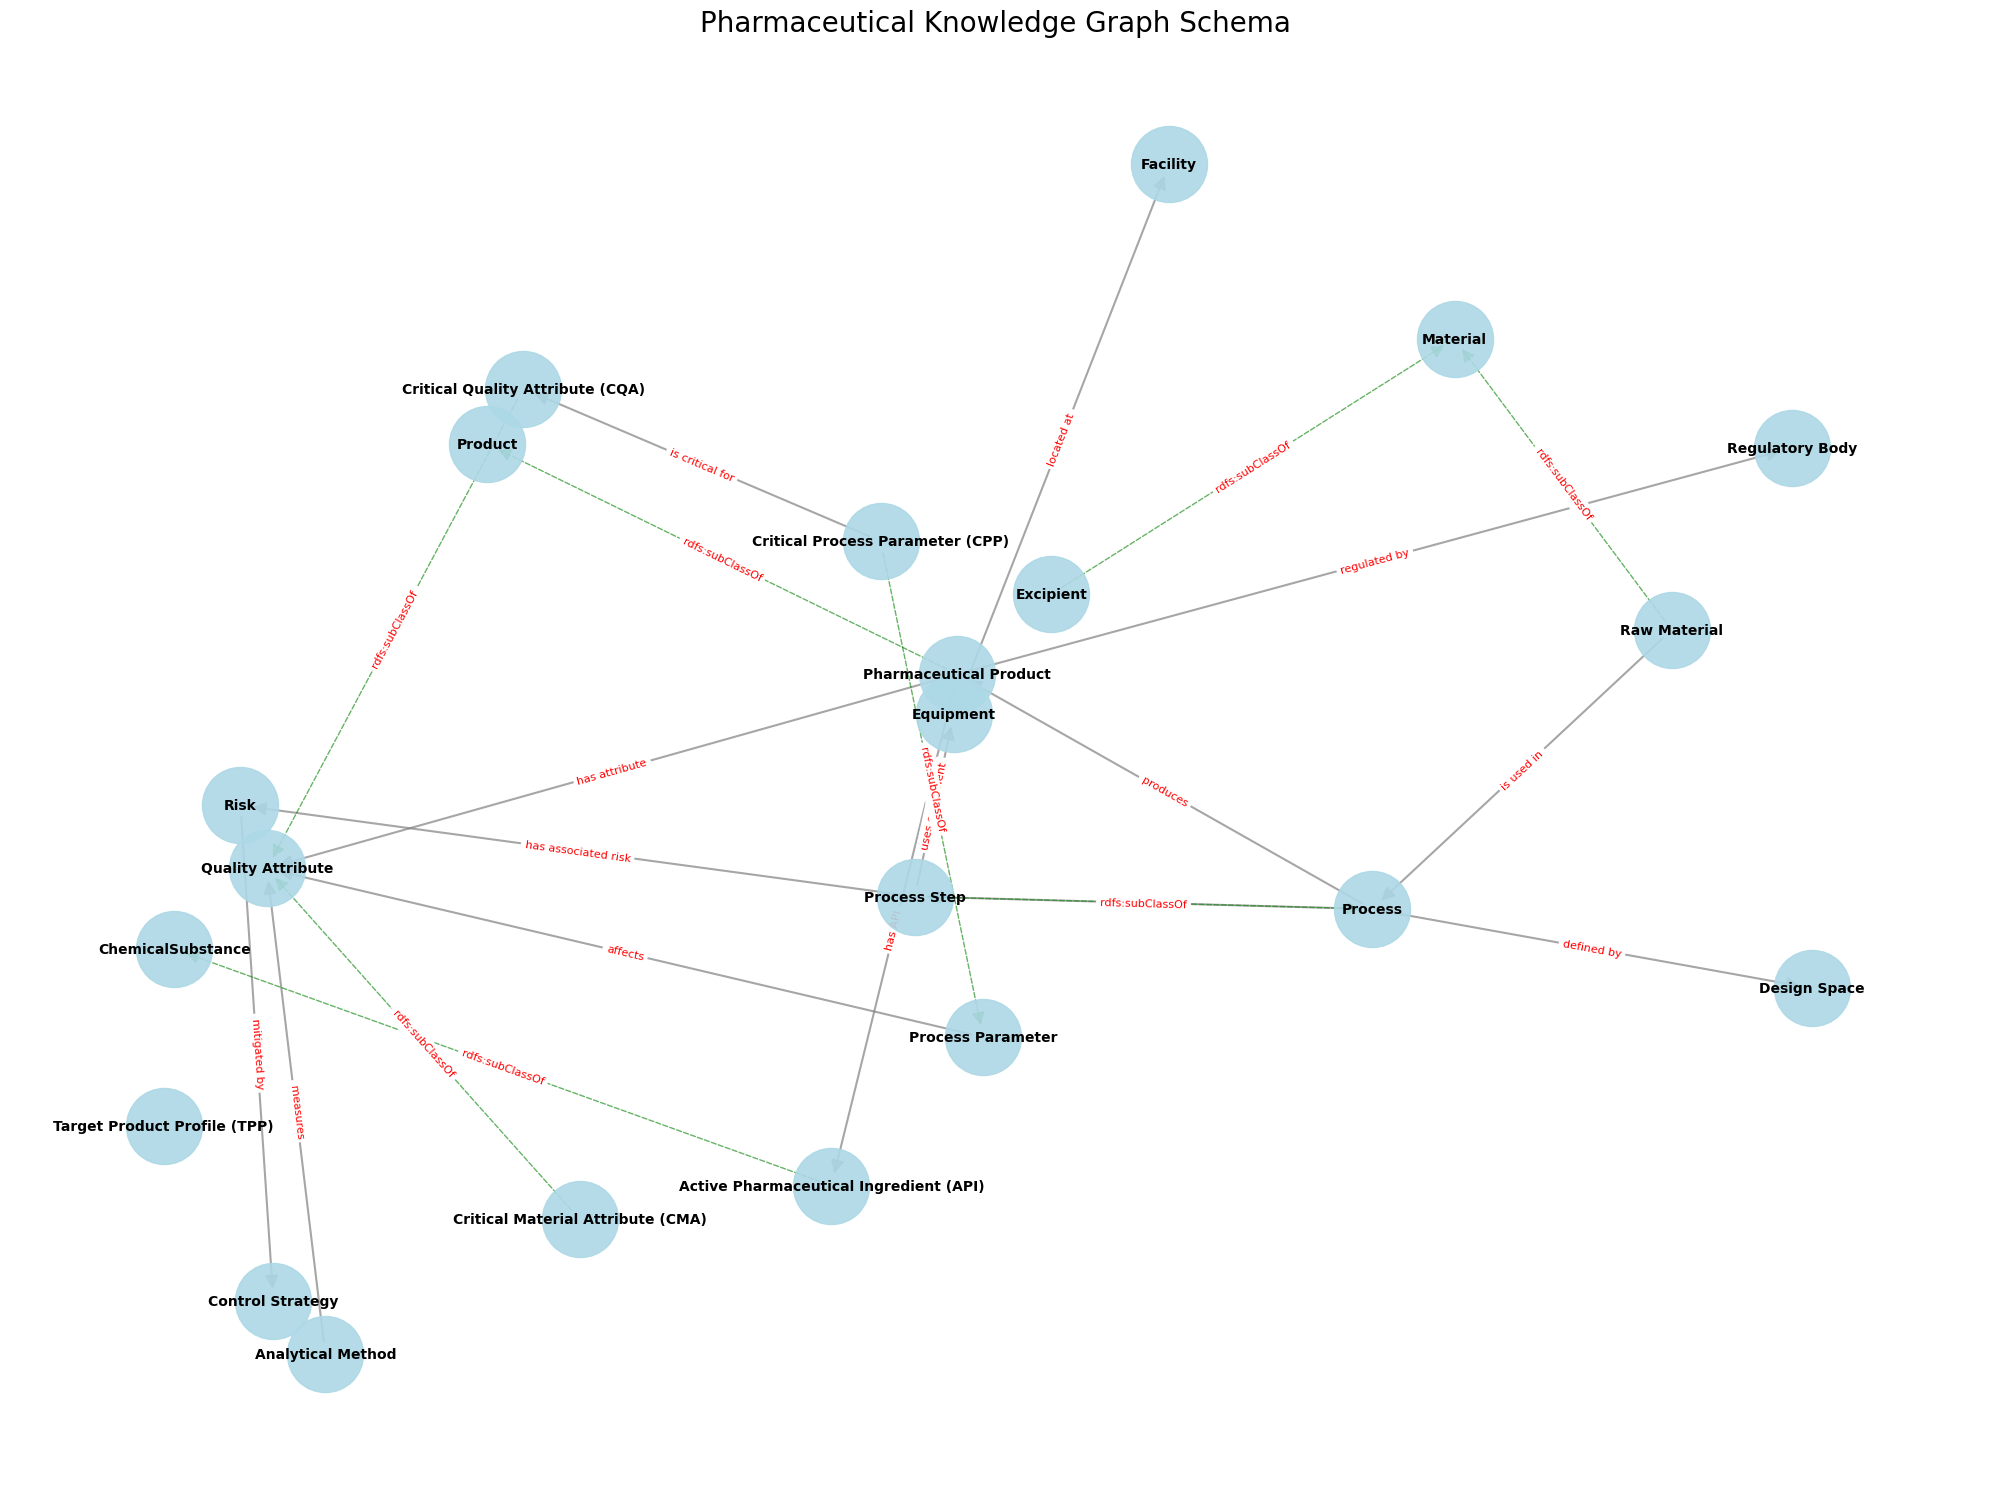

In [3]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# The JSON-LD schema was previously provided in a markdown cell. Let's assume it's stored in a string variable.
# For demonstration, I will re-create the schema string from the previous output.
# In a real Colab session, you might load this from a file or directly reference the cell content if available programmatically.

schema_json_str = '''
{
  "@context": {
    "pharm": "http://example.org/pharmaceutical-kg#",
    "xsd": "http://www.w3.org/2001/XMLSchema#",
    "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
    "owl": "http://www.w3.org/2002/07/owl#",
    "schema": "http://schema.org/",

    "PharmaceuticalProduct": "pharm:PharmaceuticalProduct",
    "ActivePharmaceuticalIngredient": "pharm:ActivePharmaceuticalIngredient",
    "Process": "pharm:Process",
    "ProcessStep": "pharm:ProcessStep",
    "RawMaterial": "pharm:RawMaterial",
    "Excipient": "pharm:Excipient",
    "QualityAttribute": "pharm:QualityAttribute",
    "CriticalQualityAttribute": "pharm:CriticalQualityAttribute",
    "CriticalMaterialAttribute": "pharm:CriticalMaterialAttribute",
    "ProcessParameter": "pharm:ProcessParameter",
    "CriticalProcessParameter": "pharm:CriticalProcessParameter",
    "RegulatoryBody": "pharm:RegulatoryBody",
    "Risk": "pharm:Risk",
    "ControlStrategy": "pharm:ControlStrategy",
    "DesignSpace": "pharm:DesignSpace",
    "TargetProductProfile": "pharm:TargetProductProfile",
    "AnalyticalMethod": "pharm:AnalyticalMethod",
    "Equipment": "pharm:Equipment",
    "Facility": "pharm:Facility",

    "hasAPI": {"@id": "pharm:hasAPI", "@type": "@id"},
    "isUsedIn": {"@id": "pharm:isUsedIn", "@type": "@id"},
    "produces": {"@id": "pharm:produces", "@type": "@id"},
    "hasStep": {"@id": "pharm:hasStep", "@type": "@id"},
    "affects": {"@id": "pharm:affects", "@type": "@id"},
    "regulatedBy": {"@id": "pharm:regulatedBy", "@type": "@id"},
    "hasAttribute": {"@id": "pharm:hasAttribute", "@type": "@id"},
    "isCriticalFor": {"@id": "pharm:isCriticalFor", "@type": "@id"},
    "mitigatedBy": {"@id": "pharm:mitigatedBy", "@type": "@id"},
    "definedBy": {"@id": "pharm:definedBy", "@type": "@id"},
    "measures": {"@id": "pharm:measures", "@type": "@id"},
    "usesEquipment": {"@id": "pharm:usesEquipment", "@type": "@id"},
    "locatedAt": {"@id": "pharm:locatedAt", "@type": "@id"},
    "hasAssociatedRisk": {"@id": "pharm:hasAssociatedRisk", "@type": "@id"},
    "hasRiskLevel": {"@id": "pharm:hasRiskLevel", "@type": "xsd:string"},
    "hasSpecification": {"@id": "pharm:hasSpecification", "@type": "xsd:string"},
    "hasUnit": {"@id": "pharm:hasUnit", "@type": "xsd:string"},
    "hasValue": {"@id": "pharm:hasValue", "@type": "xsd:string"},
    "hasMinRange": {"@id": "pharm:hasMinRange", "@type": "xsd:double"},
    "hasMaxRange": {"@id": "pharm:hasMaxRange", "@type": "xsd:double"},
    "hasDescription": "schema:description",
    "hasName": "schema:name",
    "hasURL": "schema:url"
  },
  "@graph": [
    {
      "@id": "pharm:PharmaceuticalProduct",
      "@type": "rdfs:Class",
      "rdfs:label": "Pharmaceutical Product",
      "rdfs:comment": "A finished drug product that is manufactured and marketed.",
      "rdfs:subClassOf": "schema:Product"
    },
    {
      "@id": "pharm:ActivePharmaceuticalIngredient",
      "@type": "rdfs:Class",
      "rdfs:label": "Active Pharmaceutical Ingredient (API)",
      "rdfs:comment": "The biologically active component of a drug product.",
      "rdfs:subClassOf": "schema:ChemicalSubstance"
    },
    {
      "@id": "pharm:Process",
      "@type": "rdfs:Class",
      "rdfs:label": "Process",
      "rdfs:comment": "A series of actions or steps taken in order to achieve a particular end in drug development or manufacturing."
    },
    {
      "@id": "pharm:ProcessStep",
      "@type": "rdfs:Class",
      "rdfs:label": "Process Step",
      "rdfs:comment": "An individual stage within a larger process.",
      "rdfs:subClassOf": "pharm:Process"
    },
    {
      "@id": "pharm:RawMaterial",
      "@type": "rdfs:Class",
      "rdfs:label": "Raw Material",
      "rdfs:comment": "A basic material used in the production of a drug substance or product.",
      "rdfs:subClassOf": "schema:Material"
    },
    {
      "@id": "pharm:Excipient",
      "@type": "rdfs:Class",
      "rdfs:label": "Excipient",
      "rdfs:comment": "An inactive substance used as a carrier for the active ingredients of a medication.",
      "rdfs:subClassOf": "schema:Material"
    },
    {
      "@id": "pharm:QualityAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Quality Attribute",
      "rdfs:comment": "A property or characteristic that describes the quality of a material or product."
    },
    {
      "@id": "pharm:CriticalQualityAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Quality Attribute (CQA)",
      "rdfs:comment": "A physical, chemical, biological, or microbiological property or characteristic that should be within an appropriate limit, range, or distribution to ensure the desired product quality.",
      "rdfs:subClassOf": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:CriticalMaterialAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Material Attribute (CMA)",
      "rdfs:comment": "A property or characteristic of a material that should be within an appropriate limit, range, or distribution to ensure the desired product quality.",
      "rdfs:subClassOf": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:ProcessParameter",
      "@type": "rdfs:Class",
      "rdfs:label": "Process Parameter",
      "rdfs:comment": "A variable of a manufacturing process that can be measured and controlled."
    },
    {
      "@id": "pharm:CriticalProcessParameter",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Process Parameter (CPP)",
      "rdfs:comment": "A process parameter whose variability has an impact on a critical quality attribute and therefore should be monitored or controlled to ensure the process produces the desired quality.",
      "rdfs:subClassOf": "pharm:ProcessParameter"
    },
    {
      "@id": "pharm:RegulatoryBody",
      "@type": "rdfs:Class",
      "rdfs:label": "Regulatory Body",
      "rdfs:comment": "A government agency responsible for overseeing the safety and efficacy of pharmaceutical products."
    },
    {
      "@id": "pharm:Risk",
      "@type": "rdfs:Class",
      "rdfs:label": "Risk",
      "rdfs:comment": "An uncertainty that could have an undesirable effect on product quality, safety, or efficacy."
    },
    {
      "@id": "pharm:ControlStrategy",
      "@type": "rdfs:Class",
      "rdfs:label": "Control Strategy",
      "rdfs:comment": "A set of controls derived from current product and process understanding that assures process performance and product quality."
    },
    {
      "@id": "pharm:DesignSpace",
      "@type": "rdfs:Class",
      "rdfs:label": "Design Space",
      "rdfs:comment": "The multidimensional combination and interaction of input variables and process parameters that have been demonstrated to provide assurance of quality."
    },
    {
      "@id": "pharm:TargetProductProfile",
      "@type": "rdfs:Class",
      "rdfs:label": "Target Product Profile (TPP)",
      "rdfs:comment": "A prospective summary of the characteristics of a drug product that will be developed to meet a particular medical need."
    },
    {
      "@id": "pharm:AnalyticalMethod",
      "@type": "rdfs:Class",
      "rdfs:label": "Analytical Method",
      "rdfs:comment": "A procedure used to analyze a material or product for its characteristics."
    },
    {
      "@id": "pharm:Equipment",
      "@type": "rdfs:Class",
      "rdfs:label": "Equipment",
      "rdfs:comment": "Machinery or apparatus used in the manufacturing process."
    },
    {
      "@id": "pharm:Facility",
      "@type": "rdfs:Class",
      "rdfs:label": "Facility",
      "rdfs:comment": "A building or location where pharmaceutical activities take place."
    },

    {
      "@id": "pharm:hasAPI",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has API",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:ActivePharmaceuticalIngredient"
    },
    {
      "@id": "pharm:isUsedIn",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "is used in",
      "rdfs:domain": "pharm:RawMaterial",
      "rdfs:range": "pharm:Process"
    },
    {
      "@id": "pharm:produces",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "produces",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:PharmaceuticalProduct"
    },
    {
      "@id": "pharm:hasStep",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has step",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:ProcessStep"
    },
    {
      "@id": "pharm:affects",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "affects",
      "rdfs:domain": "pharm:ProcessParameter",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:regulatedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "regulated by",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:RegulatoryBody"
    },
    {
      "@id": "pharm:hasAttribute",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has attribute",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:isCriticalFor",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "is critical for",
      "rdfs:domain": "pharm:CriticalProcessParameter",
      "rdfs:range": "pharm:CriticalQualityAttribute"
    },
    {
      "@id": "pharm:mitigatedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "mitigated by",
      "rdfs:domain": "pharm:Risk",
      "rdfs:range": "pharm:ControlStrategy"
    },
    {
      "@id": "pharm:definedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "defined by",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:DesignSpace"
    },
    {
      "@id": "pharm:measures",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "measures",
      "rdfs:domain": "pharm:AnalyticalMethod",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:usesEquipment",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "uses equipment",
      "rdfs:domain": "pharm:ProcessStep",
      "rdfs:range": "pharm:Equipment"
    },
    {
      "@id": "pharm:locatedAt",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "located at",
      "rdfs:domain": "pharm:Equipment",
      "rdfs:range": "pharm:Facility"
    },
    {
      "@id": "pharm:hasAssociatedRisk",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has associated risk",
      "rdfs:domain": "pharm:ProcessStep",
      "rdfs:range": "pharm:Risk"
    }
  ]
}
'''

def get_local_name(uri, prefix_context):
    """Extracts the local name from a URI using the provided prefix-to-base_uri mappings.
       Handles both full URIs and already compacted URIs (QNames).
    """
    if not isinstance(uri, str):
        return str(uri) # Ensure output is a string

    # If the URI is already compacted (e.g., 'pharm:PharmaceuticalProduct')
    if ':' in uri and '//' not in uri:
        prefix_part = uri.split(':', 1)[0]
        # Check if the prefix actually exists in our prefix_context
        if prefix_part in prefix_context:
            # Return the local name part if it's a known QName, otherwise return the whole URI if it was not expanded.
            return uri.split(':', 1)[1] if len(uri.split(':', 1)) > 1 else uri # Return 'PharmaceuticalProduct'

    # Attempt to compact full URIs
    for prefix, base_uri in prefix_context.items():
        if uri.startswith(base_uri):
            return prefix + ':' + uri[len(base_uri):]

    # Fallback for URIs that couldn't be compacted or were not QNames
    # Extract the last part after '/' or '#'
    return uri.split('/')[-1].split('#')[-1]

def visualize_kg_schema(schema_json_str):
    schema_data = json.loads(schema_json_str)
    raw_context = schema_data['@context']
    graph_elements = schema_data['@graph']

    # Create a filtered context that only contains prefix-URI base mappings
    # This avoids iterating over term definitions (like "hasAPI": {...}) or other non-string values.
    prefix_context = {}
    for key, value in raw_context.items():
        # Include standard prefixes and those ending with / or # as base URIs
        if isinstance(value, str) and (value.endswith('/') or value.endswith('#') or key in ['xsd', 'rdfs', 'owl', 'schema', 'pharm']):
            # Ensure it's a short prefix, not a term definition
            if key in ['pharm', 'xsd', 'rdfs', 'owl', 'schema'] or (key not in ['PharmaceuticalProduct', 'ActivePharmaceuticalIngredient', 'Process', 'ProcessStep', 'RawMaterial', 'Excipient', 'QualityAttribute', 'CriticalQualityAttribute', 'CriticalMaterialAttribute', 'ProcessParameter', 'CriticalProcessParameter', 'RegulatoryBody', 'Risk', 'ControlStrategy', 'DesignSpace', 'TargetProductProfile', 'AnalyticalMethod', 'Equipment', 'Facility'] and len(key) < 10): # Heuristic for distinguishing prefixes from terms
                prefix_context[key] = value

    G = nx.DiGraph()

    class_labels = {}
    for element in graph_elements:
        if element['@type'] == 'rdfs:Class':
            uri = element['@id']
            # Use the filtered prefix_context
            label = element.get('rdfs:label', get_local_name(uri, prefix_context))
            G.add_node(uri, label=label, type='Class')
            class_labels[uri] = label

    for element in graph_elements:
        if element['@type'] == 'owl:ObjectProperty':
            property_uri = element['@id']
            # Use the filtered prefix_context
            property_label = element.get('rdfs:label', get_local_name(property_uri, prefix_context))
            domain_uri = element.get('rdfs:domain')
            range_uri = element.get('rdfs:range')

            if domain_uri and range_uri:
                # Ensure domain and range are in the graph before adding edge
                if domain_uri not in G:
                    # Use the filtered prefix_context
                    G.add_node(domain_uri, label=get_local_name(domain_uri, prefix_context), type='ExternalClass' if isinstance(domain_uri, str) and domain_uri.startswith('http') else 'Class')
                    class_labels[domain_uri] = get_local_name(domain_uri, prefix_context)
                if range_uri not in G:
                    # Use the filtered prefix_context
                    G.add_node(range_uri, label=get_local_name(range_uri, prefix_context), type='ExternalClass' if isinstance(range_uri, str) and range_uri.startswith('http') else 'Class')
                    class_labels[range_uri] = get_local_name(range_uri, prefix_context)

                G.add_edge(domain_uri, range_uri, label=property_label, type='ObjectProperty')
        elif element['@type'] == 'rdfs:Class' and 'rdfs:subClassOf' in element:
            sub_class_uri = element['@id']
            super_class_uri = element['rdfs:subClassOf']

            if isinstance(super_class_uri, list):
                for sc_uri in super_class_uri:
                    if sc_uri not in G:
                        # Use the filtered prefix_context
                        G.add_node(sc_uri, label=get_local_name(sc_uri, prefix_context), type='ExternalClass' if isinstance(sc_uri, str) and sc_uri.startswith('http') else 'Class')
                        class_labels[sc_uri] = get_local_name(sc_uri, prefix_context)
                    G.add_edge(sub_class_uri, sc_uri, label='rdfs:subClassOf', type='Inheritance')
            else:
                if super_class_uri not in G:
                    # Use the filtered prefix_context
                    G.add_node(super_class_uri, label=get_local_name(super_class_uri, prefix_context), type='ExternalClass' if isinstance(super_class_uri, str) and super_class_uri.startswith('http') else 'Class')
                    class_labels[super_class_uri] = get_local_name(super_class_uri, prefix_context)
                G.add_edge(sub_class_uri, super_class_uri, label='rdfs:subClassOf', type='Inheritance')


    plt.figure(figsize=(20, 15))
    pos = nx.spring_layout(G, k=0.8, iterations=50) # Use spring layout for better node separation

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.9)

    # Draw edges with different styles for object properties and inheritance
    object_property_edges = [(u, v) for u, v, attrs in G.edges(data=True) if attrs.get('type') == 'ObjectProperty']
    inheritance_edges = [(u, v) for u, v, attrs in G.edges(data=True) if attrs.get('type') == 'Inheritance']

    nx.draw_networkx_edges(G, pos, edgelist=object_property_edges, arrowsize=20, edge_color='gray', width=1.5, alpha=0.7, style='solid')
    nx.draw_networkx_edges(G, pos, edgelist=inheritance_edges, arrowsize=20, edge_color='green', width=1.0, alpha=0.6, style='dashed', label='subClassOf')

    # Draw node labels using the extracted labels
    node_labels = {node: G.nodes[node]['label'] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')

    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    plt.title('Pharmaceutical Knowledge Graph Schema', size=20)
    plt.axis('off') # Hide axes
    plt.tight_layout()
    plt.show()

visualize_kg_schema(schema_json_str)


In [4]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.1 MB/s eta 0:00:00


In [5]:
from pyvis.network import Network

def create_interactive_pyvis_network(nx_graph, prefix_context):
    """Creates an interactive Pyvis network from a NetworkX graph."""
    net = Network(notebook=True, cdn_resources='remote', height='750px', width='100%',
                  bgcolor='#222222', font_color='white', select_menu=True, filter_menu=True)

    # Add nodes to Pyvis network
    for node_id, data in nx_graph.nodes(data=True):
        label = data.get('label', get_local_name(node_id, prefix_context))
        node_type = data.get('type', 'Unknown')

        title_info = f"<b>Label:</b> {label}<br><b>ID:</b> {node_id}<br><b>Type:</b> {node_type}"

        # Customize node colors based on type
        color = 'lightblue' # Default for Classes
        if node_type == 'ExternalClass':
            color = 'lightcoral'

        net.add_node(node_id, label=label, title=title_info, color=color, shape='dot', size=15)

    # Add edges to Pyvis network
    for u, v, data in nx_graph.edges(data=True):
        edge_label = data.get('label', 'relation')
        edge_type = data.get('type', 'Unknown')

        # Customize edge colors and styles based on type
        color = 'gray' # Default for ObjectProperties
        dashes = False
        if edge_type == 'Inheritance':
            color = 'green'
            dashes = True

        net.add_edge(u, v, title=edge_label, label=edge_label, color=color, dashes=dashes, arrowStrikethrough=False)

    # Optionally, add physics for better layout
    net.toggle_physics(True)

    # Generate and display the interactive network
    # The generated HTML file will be saved in the Colab environment
    net.show("pharm_kg_interactive_pyvis.html")
    print("Interactive Pyvis network saved to pharm_kg_interactive_pyvis.html")

# Assuming G (NetworkX graph) and prefix_context are available from previous cells
# (e.g., from the visualize_kg_schema function scope or global variables if defined globally)
# If G and prefix_context are not global, you might need to re-run the visualize_kg_schema
# function once more and extract G and prefix_context if not already done.

# For simplicity, assuming G and prefix_context are available from the last successful execution of visualize_kg_schema
# If not, you might need to extract them by re-running the visualization code and modifying it slightly

# --- Re-extracting G and prefix_context for this cell to be self-contained if needed ---
# This part assumes you executed the previous cell `e96b8229` which defined `schema_json_str`,
# and you want to use the `visualize_kg_schema` function to reconstruct G and prefix_context

# Parse the schema data again to get G and prefix_context
# NOTE: This is a simplified way to get G and prefix_context for this new cell.
# In a real scenario, you might want to refactor `visualize_kg_schema` to return G and prefix_context.

schema_data = json.loads(schema_json_str)
raw_context = schema_data['@context']
graph_elements = schema_data['@graph']

prefix_context = {}
for key, value in raw_context.items():
    if isinstance(value, str) and (value.endswith('/') or value.endswith('#') or key in ['xsd', 'rdfs', 'owl', 'schema', 'pharm']):
        if key in ['pharm', 'xsd', 'rdfs', 'owl', 'schema'] or (key not in ['PharmaceuticalProduct', 'ActivePharmaceuticalIngredient', 'Process', 'ProcessStep', 'RawMaterial', 'Excipient', 'QualityAttribute', 'CriticalQualityAttribute', 'CriticalMaterialAttribute', 'ProcessParameter', 'CriticalProcessParameter', 'RegulatoryBody', 'Risk', 'ControlStrategy', 'DesignSpace', 'TargetProductProfile', 'AnalyticalMethod', 'Equipment', 'Facility'] and len(key) < 10):
            prefix_context[key] = value

G = nx.DiGraph()

for element in graph_elements:
    if element['@type'] == 'rdfs:Class':
        uri = element['@id']
        label = element.get('rdfs:label', get_local_name(uri, prefix_context))
        G.add_node(uri, label=label, type='Class')

for element in graph_elements:
    if element['@type'] == 'owl:ObjectProperty':
        property_uri = element['@id']
        property_label = element.get('rdfs:label', get_local_name(property_uri, prefix_context))
        domain_uri = element.get('rdfs:domain')
        range_uri = element.get('rdfs:range')

        if domain_uri and range_uri:
            if domain_uri not in G:
                G.add_node(domain_uri, label=get_local_name(domain_uri, prefix_context), type='ExternalClass' if isinstance(domain_uri, str) and domain_uri.startswith('http') else 'Class')
            if range_uri not in G:
                G.add_node(range_uri, label=get_local_name(range_uri, prefix_context), type='ExternalClass' if isinstance(range_uri, str) and range_uri.startswith('http') else 'Class')

            G.add_edge(domain_uri, range_uri, label=property_label, type='ObjectProperty')
    elif element['@type'] == 'rdfs:Class' and 'rdfs:subClassOf' in element:
        sub_class_uri = element['@id']
        super_class_uri = element['rdfs:subClassOf']

        if isinstance(super_class_uri, list):
            for sc_uri in super_class_uri:
                if sc_uri not in G:
                    G.add_node(sc_uri, label=get_local_name(sc_uri, prefix_context), type='ExternalClass' if isinstance(sc_uri, str) and sc_uri.startswith('http') else 'Class')
                G.add_edge(sub_class_uri, sc_uri, label='rdfs:subClassOf', type='Inheritance')
        else:
            if super_class_uri not in G:
                G.add_node(super_class_uri, label=get_local_name(super_class_uri, prefix_context), type='ExternalClass' if isinstance(super_class_uri, str) and super_class_uri.startswith('http') else 'Class')
            G.add_edge(sub_class_uri, super_class_uri, label='rdfs:subClassOf', type='Inheritance')


# Call the function to create and display the interactive Pyvis network
create_interactive_pyvis_network(G, prefix_context)


pharm_kg_interactive_pyvis.html
Interactive Pyvis network saved to pharm_kg_interactive_pyvis.html


```json
{
  "@context": {
    "pharm": "http://example.org/pharmaceutical-kg#",
    "xsd": "http://www.w3.org/2001/XMLSchema#",
    "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
    "owl": "http://www.w3.org/2002/07/owl#",
    "schema": "http://schema.org/",

    "PharmaceuticalProduct": "pharm:PharmaceuticalProduct",
    "ActivePharmaceuticalIngredient": "pharm:ActivePharmaceuticalIngredient",
    "Process": "pharm:Process",
    "ProcessStep": "pharm:ProcessStep",
    "RawMaterial": "pharm:RawMaterial",
    "Excipient": "pharm:Excipient",
    "QualityAttribute": "pharm:QualityAttribute",
    "CriticalQualityAttribute": "pharm:CriticalQualityAttribute",
    "CriticalMaterialAttribute": "pharm:CriticalMaterialAttribute",
    "ProcessParameter": "pharm:ProcessParameter",
    "CriticalProcessParameter": "pharm:CriticalProcessParameter",
    "RegulatoryBody": "pharm:RegulatoryBody",
    "Risk": "pharm:Risk",
    "ControlStrategy": "pharm:ControlStrategy",
    "DesignSpace": "pharm:DesignSpace",
    "TargetProductProfile": "pharm:TargetProductProfile",
    "AnalyticalMethod": "pharm:AnalyticalMethod",
    "Equipment": "pharm:Equipment",
    "Facility": "pharm:Facility",

    "hasAPI": {"@id": "pharm:hasAPI", "@type": "@id"},
    "isUsedIn": {"@id": "pharm:isUsedIn", "@type": "@id"},
    "produces": {"@id": "pharm:produces", "@type": "@id"},
    "hasStep": {"@id": "pharm:hasStep", "@type": "@id"},
    "affects": {"@id": "pharm:affects", "@type": "@id"},
    "regulatedBy": {"@id": "pharm:regulatedBy", "@type": "@id"},
    "hasAttribute": {"@id": "pharm:hasAttribute", "@type": "@id"},
    "isCriticalFor": {"@id": "pharm:isCriticalFor", "@type": "@id"},
    "mitigatedBy": {"@id": "pharm:mitigatedBy", "@type": "@id"},
    "definedBy": {"@id": "pharm:definedBy", "@type": "@id"},
    "measures": {"@id": "pharm:measures", "@type": "@id"},
    "usesEquipment": {"@id": "pharm:usesEquipment", "@type": "@id"},
    "locatedAt": {"@id": "pharm:locatedAt", "@type": "@id"},
    "hasAssociatedRisk": {"@id": "pharm:hasAssociatedRisk", "@type": "@id"},
    "hasRiskLevel": {"@id": "pharm:hasRiskLevel", "@type": "xsd:string"},
    "hasSpecification": {"@id": "pharm:hasSpecification", "@type": "xsd:string"},
    "hasUnit": {"@id": "pharm:hasUnit", "@type": "xsd:string"},
    "hasValue": {"@id": "pharm:hasValue", "@type": "xsd:string"},
    "hasMinRange": {"@id": "pharm:hasMinRange", "@type": "xsd:double"},
    "hasMaxRange": {"@id": "pharm:hasMaxRange", "@type": "xsd:double"},
    "hasDescription": "schema:description",
    "hasName": "schema:name",
    "hasURL": "schema:url"
  },
  "@graph": [
    {
      "@id": "pharm:PharmaceuticalProduct",
      "@type": "rdfs:Class",
      "rdfs:label": "Pharmaceutical Product",
      "rdfs:comment": "A finished drug product that is manufactured and marketed.",
      "rdfs:subClassOf": "schema:Product"
    },
    {
      "@id": "pharm:ActivePharmaceuticalIngredient",
      "@type": "rdfs:Class",
      "rdfs:label": "Active Pharmaceutical Ingredient (API)",
      "rdfs:comment": "The biologically active component of a drug product.",
      "rdfs:subClassOf": "schema:ChemicalSubstance"
    },
    {
      "@id": "pharm:Process",
      "@type": "rdfs:Class",
      "rdfs:label": "Process",
      "rdfs:comment": "A series of actions or steps taken in order to achieve a particular end in drug development or manufacturing."
    },
    {
      "@id": "pharm:ProcessStep",
      "@type": "rdfs:Class",
      "rdfs:label": "Process Step",
      "rdfs:comment": "An individual stage within a larger process.",
      "rdfs:subClassOf": "pharm:Process"
    },
    {
      "@id": "pharm:RawMaterial",
      "@type": "rdfs:Class",
      "rdfs:label": "Raw Material",
      "rdfs:comment": "A basic material used in the production of a drug substance or product.",
      "rdfs:subClassOf": "schema:Material"
    },
    {
      "@id": "pharm:Excipient",
      "@type": "rdfs:Class",
      "rdfs:label": "Excipient",
      "rdfs:comment": "An inactive substance used as a carrier for the active ingredients of a medication.",
      "rdfs:subClassOf": "schema:Material"
    },
    {
      "@id": "pharm:QualityAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Quality Attribute",
      "rdfs:comment": "A property or characteristic that describes the quality of a material or product."
    },
    {
      "@id": "pharm:CriticalQualityAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Quality Attribute (CQA)",
      "rdfs:comment": "A physical, chemical, biological, or microbiological property or characteristic that should be within an appropriate limit, range, or distribution to ensure the desired product quality.",
      "rdfs:subClassOf": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:CriticalMaterialAttribute",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Material Attribute (CMA)",
      "rdfs:comment": "A property or characteristic of a material that should be within an appropriate limit, range, or distribution to ensure the desired product quality.",
      "rdfs:subClassOf": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:ProcessParameter",
      "@type": "rdfs:Class",
      "rdfs:label": "Process Parameter",
      "rdfs:comment": "A variable of a manufacturing process that can be measured and controlled."
    },
    {
      "@id": "pharm:CriticalProcessParameter",
      "@type": "rdfs:Class",
      "rdfs:label": "Critical Process Parameter (CPP)",
      "rdfs:comment": "A process parameter whose variability has an impact on a critical quality attribute and therefore should be monitored or controlled to ensure the process produces the desired quality.",
      "rdfs:subClassOf": "pharm:ProcessParameter"
    },
    {
      "@id": "pharm:RegulatoryBody",
      "@type": "rdfs:Class",
      "rdfs:label": "Regulatory Body",
      "rdfs:comment": "A government agency responsible for overseeing the safety and efficacy of pharmaceutical products."
    },
    {
      "@id": "pharm:Risk",
      "@type": "rdfs:Class",
      "rdfs:label": "Risk",
      "rdfs:comment": "An uncertainty that could have an undesirable effect on product quality, safety, or efficacy."
    },
    {
      "@id": "pharm:ControlStrategy",
      "@type": "rdfs:Class",
      "rdfs:label": "Control Strategy",
      "rdfs:comment": "A set of controls derived from current product and process understanding that assures process performance and product quality."
    },
    {
      "@id": "pharm:DesignSpace",
      "@type": "rdfs:Class",
      "rdfs:label": "Design Space",
      "rdfs:comment": "The multidimensional combination and interaction of input variables and process parameters that have been demonstrated to provide assurance of quality."
    },
    {
      "@id": "pharm:TargetProductProfile",
      "@type": "rdfs:Class",
      "rdfs:label": "Target Product Profile (TPP)",
      "rdfs:comment": "A prospective summary of the characteristics of a drug product that will be developed to meet a particular medical need."
    },
    {
      "@id": "pharm:AnalyticalMethod",
      "@type": "rdfs:Class",
      "rdfs:label": "Analytical Method",
      "rdfs:comment": "A procedure used to analyze a material or product for its characteristics."
    },
    {
      "@id": "pharm:Equipment",
      "@type": "rdfs:Class",
      "rdfs:label": "Equipment",
      "rdfs:comment": "Machinery or apparatus used in the manufacturing process."
    },
    {
      "@id": "pharm:Facility",
      "@type": "rdfs:Class",
      "rdfs:label": "Facility",
      "rdfs:comment": "A building or location where pharmaceutical activities take place."
    },
    
    {
      "@id": "pharm:hasAPI",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has API",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:ActivePharmaceuticalIngredient"
    },
    {
      "@id": "pharm:isUsedIn",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "is used in",
      "rdfs:domain": "pharm:RawMaterial",
      "rdfs:range": "pharm:Process"
    },
    {
      "@id": "pharm:produces",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "produces",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:PharmaceuticalProduct"
    },
    {
      "@id": "pharm:hasStep",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has step",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:ProcessStep"
    },
    {
      "@id": "pharm:affects",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "affects",
      "rdfs:domain": "pharm:ProcessParameter",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:regulatedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "regulated by",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:RegulatoryBody"
    },
    {
      "@id": "pharm:hasAttribute",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has attribute",
      "rdfs:domain": "pharm:PharmaceuticalProduct",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:isCriticalFor",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "is critical for",
      "rdfs:domain": "pharm:CriticalProcessParameter",
      "rdfs:range": "pharm:CriticalQualityAttribute"
    },
    {
      "@id": "pharm:mitigatedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "mitigated by",
      "rdfs:domain": "pharm:Risk",
      "rdfs:range": "pharm:ControlStrategy"
    },
    {
      "@id": "pharm:definedBy",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "defined by",
      "rdfs:domain": "pharm:Process",
      "rdfs:range": "pharm:DesignSpace"
    },
    {
      "@id": "pharm:measures",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "measures",
      "rdfs:domain": "pharm:AnalyticalMethod",
      "rdfs:range": "pharm:QualityAttribute"
    },
    {
      "@id": "pharm:usesEquipment",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "uses equipment",
      "rdfs:domain": "pharm:ProcessStep",
      "rdfs:range": "pharm:Equipment"
    },
    {
      "@id": "pharm:locatedAt",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "located at",
      "rdfs:domain": "pharm:Equipment",
      "rdfs:range": "pharm:Facility"
    },
    {
      "@id": "pharm:hasAssociatedRisk",
      "@type": "owl:ObjectProperty",
      "rdfs:label": "has associated risk",
      "rdfs:domain": "pharm:ProcessStep",
      "rdfs:range": "pharm:Risk"
    }
  ]
}
```